In [ ]:
!pip -q install rouge-score nltk


  Preparing metadata (setup.py) ... done


In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Medical_Reportss.csv to Medical_Reportss (2).csv


In [ ]:
df = pd.read_csv("Medical_Reportss (2).csv")
df.head()

,Report_ID,Age,Gender,Condition,Follow_Up_Weeks,Medical_Report
0,MR2271,41.0,Female,Migraine,12.0,"A 41-year-old female patient was evaluated for Migraine. At the initial assessment, the patient reported nausea, rec..."
1,MR0443,37.0,Female,Knee Osteoarthritis,8.0,"A 37-year-old female patient was evaluated for Knee Osteoarthritis. At the initial assessment, the patient reported ..."
2,MR2887,63.0,Female,Hypothyroidism,4.0,"A 63-year-old female patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported weigh..."
3,MR1656,71.0,Male,Hypothyroidism,12.0,"A 71-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported fatigue..."
4,MR1002,54.0,Male,Hypothyroidism,NaN,"A 54-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported cold in..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3176 entries, 0 to 3175
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Report_ID        3176 non-null   object 
 1   Age              3000 non-null   float64
 2   Gender           3019 non-null   object 
 3   Condition        3016 non-null   object 
 4   Follow_Up_Weeks  3012 non-null   float64
 5   Medical_Report   3015 non-null   object 
dtypes: float64(2), object(4)
memory usage: 149.0+ KB


In [ ]:
print(df.isnull().sum())

Report_ID            0
Age                176
Gender             157
Condition          160
Follow_Up_Weeks    164
Medical_Report     161
dtype: int64


In [ ]:
print(df.duplicated().sum())

166


In [ ]:
print(df["Condition"].nunique())

10


In [ ]:
print(df["Condition"].value_counts())

Condition
Migraine                           346
Asthma                             327
Community-Acquired Pneumonia       321
Type 2 Diabetes Mellitus           303
Hypertension                       302
Gastroesophageal Reflux Disease    295
Iron-Deficiency Anemia             290
Hypothyroidism                     283
Urinary Tract Infection            277
Knee Osteoarthritis                272
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates().copy()

In [ ]:
# Remove rows where Medical_Report is missing
df = df.dropna(subset=["Medical_Report"])

In [ ]:
# Fill missing categorical values
df["Condition"] = df["Condition"].fillna("Unknown")
df["Gender"] = df["Gender"].fillna("Unknown")

In [ ]:
# Fill numerical missing values with median
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Follow_Up_Weeks"] = df["Follow_Up_Weeks"].fillna(
    df["Follow_Up_Weeks"].median()
)


In [ ]:
# Clean medical text
def clean_text(text):

    text = str(text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove unwanted special characters
    # Keep medical punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,;:()\-/%]', '', text)

    return text.strip()


df["Cleaned_Report"] = df["Medical_Report"].apply(clean_text)

print("Shape after cleaning:", df.shape)

display(
    df[
        ["Report_ID", "Condition", "Medical_Report", "Cleaned_Report"]
    ].head()
)


Shape after cleaning: (2855, 7)


,Report_ID,Condition,Medical_Report,Cleaned_Report
0,MR2271,Migraine,"A 41-year-old female patient was evaluated for Migraine. At the initial assessment, the patient reported nausea, rec...","A 41-year-old female patient was evaluated for Migraine. At the initial assessment, the patient reported nausea, rec..."
1,MR0443,Knee Osteoarthritis,"A 37-year-old female patient was evaluated for Knee Osteoarthritis. At the initial assessment, the patient reported ...","A 37-year-old female patient was evaluated for Knee Osteoarthritis. At the initial assessment, the patient reported ..."
2,MR2887,Hypothyroidism,"A 63-year-old female patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported weigh...","A 63-year-old female patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported weigh..."
3,MR1656,Hypothyroidism,"A 71-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported fatigue...","A 71-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported fatigue..."
4,MR1002,Hypothyroidism,"A 54-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported cold in...","A 54-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported cold in..."


In [ ]:
# ============================================================
# 5. SIMPLE EDA
# ============================================================

# Report length
df["Report_Length"] = df["Cleaned_Report"].apply(
    lambda x: len(x.split())
)

print(df["Report_Length"].describe())


count    2855.000000
mean      108.049387
std         3.064252
min       101.000000
25%       106.000000
50%       108.000000
75%       110.000000
max       118.000000
Name: Report_Length, dtype: float64


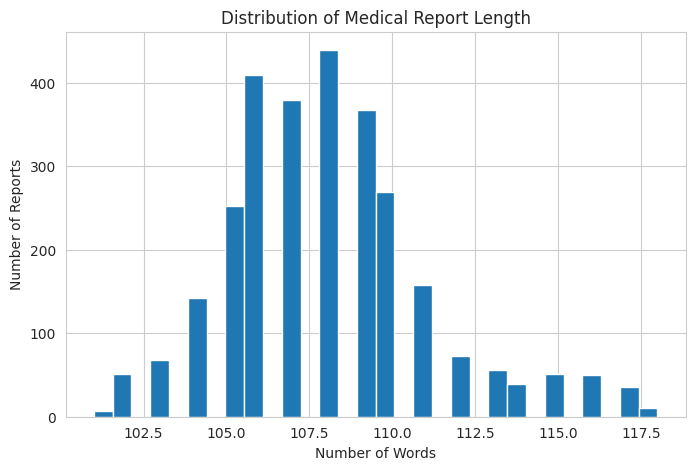

In [ ]:
# Plot report length
plt.figure(figsize=(8, 5))
plt.hist(df["Report_Length"], bins=30)
plt.xlabel("Number of Words")
plt.ylabel("Number of Reports")
plt.title("Distribution of Medical Report Length")
plt.show()


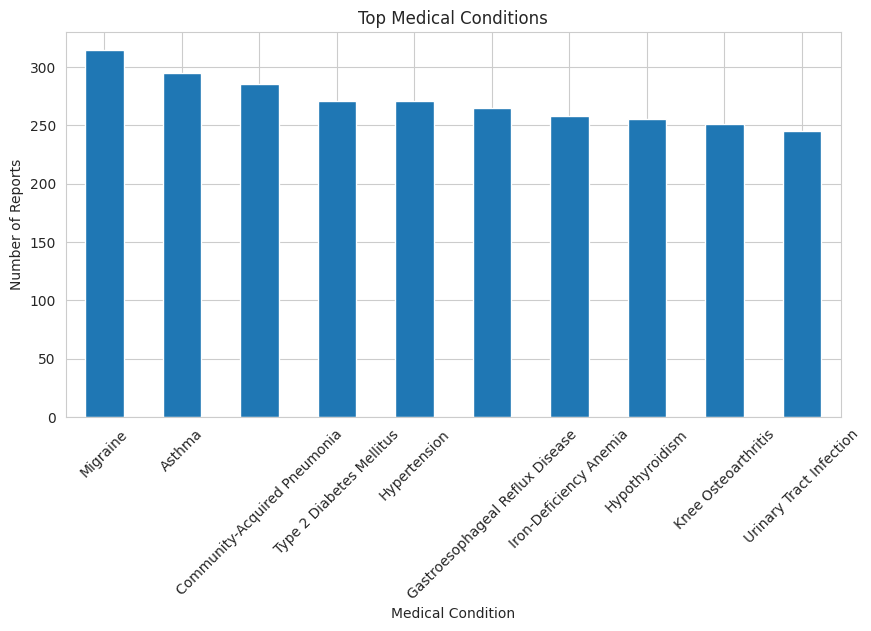

In [ ]:
# Top conditions
plt.figure(figsize=(10, 5))

df["Condition"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Medical Condition")
plt.ylabel("Number of Reports")
plt.title("Top Medical Conditions")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# ============================================================
# 6. OPTIONAL MACHINE LEARNING MODEL
# CONDITION PREDICTION FROM MEDICAL REPORT
# ============================================================

# This section demonstrates traditional ML concepts:
# 1. Features
# 2. Target
# 3. Train-test split
# 4. TF-IDF
# 5. Model training
# 6. Prediction
# 7. Accuracy
# 8. Evaluation


X = df["Cleaned_Report"]
y = df["Condition"]

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)


X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)



In [ ]:
print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (2284, 1087)
Testing Shape: (571, 1087)


In [ ]:
# ============================================================
# 7. TRAIN MACHINE LEARNING MODEL
# ============================================================

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [ ]:
# Prediction
y_pred = model.predict(X_test_tfidf)

In [ ]:
# ============================================================
# 8. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Model Accuracy: 94.92 %

Classification Report:
                                 precision    recall  f1-score   support

                         Asthma       0.97      1.00      0.98        59
   Community-Acquired Pneumonia       0.92      1.00      0.96        57
Gastroesophageal Reflux Disease       0.96      1.00      0.98        53
                   Hypertension       0.93      1.00      0.96        54
                 Hypothyroidism       0.96      1.00      0.98        51
         Iron-Deficiency Anemia       1.00      1.00      1.00        52
            Knee Osteoarthritis       0.93      1.00      0.96        50
                       Migraine       0.94      1.00      0.97        63
       Type 2 Diabetes Mellitus       0.93      1.00      0.96        54
                        Unknown       0.00      0.00      0.00        29
        Urinary Tract Infection       0.96      1.00      0.98        49

                       accuracy                           0.95       571
 

In [ ]:
# ============================================================
# 9. NLP - KEY FINDINGS EXTRACTION
# ============================================================

# Extract important clinical sentences from the report
# based on medically meaningful keywords.

clinical_keywords = [
    "reported",
    "diagnosed",
    "assessment",
    "symptom",
    "pain",
    "improved",
    "decreased",
    "reduced",
    "increased",
    "treatment",
    "follow-up",
    "response",
    "severity",
    "tolerated",
    "function",
    "frequency",
    "markers"
]

In [ ]:
def extract_key_findings(report, max_findings=4):

    sentences = sent_tokenize(str(report))

    findings = []

    for sentence in sentences:

        sentence_lower = sentence.lower()

        if any(
            keyword in sentence_lower
            for keyword in clinical_keywords
        ):
            findings.append(sentence.strip())

    # Remove duplicate findings
    findings = list(dict.fromkeys(findings))

    # Limit findings
    findings = findings[:max_findings]

    if len(findings) == 0:
        return "No major clinical findings identified."

    return " | ".join(findings)



In [ ]:
df["Key_Findings"] = df["Cleaned_Report"].apply(
    extract_key_findings
)


In [ ]:
print("\nExample Key Findings:")

print(df["Key_Findings"].iloc[0])




Example Key Findings:
At the initial assessment, the patient reported nausea, recurrent headache, and reduced daily activity during attacks. | A structured management plan was initiated, including symptom diary, sleep routine counseling, and preventive medication. | The patient was monitored over a 12-week follow-up period with regular clinical assessments. | During follow-up, daily functioning improved.


In [ ]:
# ============================================================
# 10. NLP SUMMARIZATION MODEL
# ============================================================

!pip install -q -U transformers accelerate sentencepiece

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "sshleifer/distilbart-cnn-12-6"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Summarization model loaded successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 65.4 MB/s eta 0:00:00


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.22GB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Summarization model loaded successfully!


In [ ]:
# ============================================================
# 11. SUMMARY GENERATION FUNCTION
# ============================================================

def generate_summary(report):

    # Convert report to string
    report = str(report)

    # Tokenize report
    inputs = tokenizer(
        report,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    )

    # Generate summary
    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=150,
        min_length=30,
        num_beams=4,
        early_stopping=True
    )

    # Decode generated summary
    summary = tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True
    )

    return summary

In [ ]:
# ============================================================
# 12. TEST SUMMARIZATION ON ONE REPORT
# ============================================================

sample_report = df["Cleaned_Report"].iloc[0]

print("\nORIGINAL MEDICAL REPORT:\n")
print(sample_report)

print("\nKEY FINDINGS:\n")
print(extract_key_findings(sample_report))

print("\nAI GENERATED SUMMARY:\n")
print(generate_summary(sample_report))


ORIGINAL MEDICAL REPORT:

A 41-year-old female patient was evaluated for Migraine. At the initial assessment, the patient reported nausea, recurrent headache, and reduced daily activity during attacks. A structured management plan was initiated, including symptom diary, sleep routine counseling, and preventive medication. The patient was monitored over a 12-week follow-up period with regular clinical assessments. During follow-up, daily functioning improved. In addition, headache frequency decreased. By the end of the observation period, attack severity was reduced. Overall, the patient demonstrated a favorable response to the management plan. Continued follow-up and appropriate clinical monitoring were recommended to assess sustained improvement and identify any future changes in the patients condition.

KEY FINDINGS:

At the initial assessment, the patient reported nausea, recurrent headache, and reduced daily activity during attacks. | A structured management plan was initiated, in

In [ ]:

# ============================================================
# 13. GENERATE KEY FINDINGS AND SUMMARIES
# ============================================================

# First test on only 10 reports
sample_df = df.head(10).copy()

print("Generating Key Findings...")

sample_df["Key_Findings"] = sample_df[
    "Cleaned_Report"
].apply(extract_key_findings)

print("Generating AI Summaries...")

sample_df["Generated_Summary"] = sample_df[
    "Cleaned_Report"
].apply(generate_summary)

print("Generation completed!")


Generating Key Findings...
Generating AI Summaries...
Generation completed!


In [ ]:
# ============================================================
# 14. DISPLAY FINAL RESULTS
# ============================================================

# Select only columns that exist
result = sample_df[
    [
        "Report_ID",
        "Condition",
        "Medical_Report",
        "Key_Findings",
        "Generated_Summary"
    ]
]

display(result)


,Report_ID,Condition,Medical_Report,Key_Findings,Generated_Summary
0,MR2271,Migraine,"A 41-year-old female patient was evaluated for Migraine. At the initial assessment, the patient reported nausea, rec...","At the initial assessment, the patient reported nausea, recurrent headache, and reduced daily activity during attack...","A 41-year-old female patient was evaluated for Migraine . A structured management plan was initiated, including sym..."
1,MR0443,Knee Osteoarthritis,"A 37-year-old female patient was evaluated for Knee Osteoarthritis. At the initial assessment, the patient reported ...","At the initial assessment, the patient reported chronic knee pain, reduced walking tolerance, and difficulty climbin...","A 37-year-old female patient was evaluated for Knee Osteoarthritis . A structured management plan was initiated, in..."
2,MR2887,Hypothyroidism,"A 63-year-old female patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported weigh...","At the initial assessment, the patient reported weight gain, elevated thyroid-stimulating hormone, and fatigue. | A ...","A 63-year-old female patient was evaluated for Hypothyroidism . The patient reported weight gain, elevated thyroid-..."
3,MR1656,Hypothyroidism,"A 71-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported fatigue...","At the initial assessment, the patient reported fatigue, cold intolerance, and elevated thyroid-stimulating hormone....","A 71-year-old male patient was evaluated for Hypothyroidism . A structured management plan was initiated, including..."
4,MR1002,Hypothyroidism,"A 54-year-old male patient was evaluated for Hypothyroidism. At the initial assessment, the patient reported cold in...","At the initial assessment, the patient reported cold intolerance, elevated thyroid-stimulating hormone, and weight g...","A 54-year-old male patient was evaluated for Hypothyroidism . The patient reported cold intolerance, elevated thyro..."
5,MR2565,Unknown,"A 23-year-old female patient was evaluated for Type 2 Diabetes Mellitus. At the initial assessment, the patient repo...","At the initial assessment, the patient reported fatigue, elevated fasting blood glucose, and increased thirst. | The...",A 23-year-old female patient was evaluated for Type 2 Diabetes Mellitus . A structured management plan was initiate...
6,MR1772,Urinary Tract Infection,"A 43-year-old female patient was evaluated for Urinary Tract Infection. At the initial assessment, the patient repor...","At the initial assessment, the patient reported increased urinary frequency, lower abdominal discomfort, and positiv...",A 43-year-old female patient was evaluated for Urinary Tract Infection . A structured management plan was initiated...
7,MR2340,Asthma,"A 23-year-old male patient was evaluated for Asthma. At the initial assessment, the patient reported episodic wheezi...","At the initial assessment, the patient reported episodic wheezing, shortness of breath, and chest tightness. | A str...","A 23-year-old male patient was evaluated for Asthma . At the initial assessment, the patient reported episodic whee..."
8,MR0215,Urinary Tract Infection,"A 32-year-old male patient was evaluated for Urinary Tract Infection. At the initial assessment, the patient reporte...","At the initial assessment, the patient reported lower abdominal discomfort, positive urine findings, and painful uri...",A 32-year-old male patient was evaluated for Urinary Tract Infection . The patient reported lower abdominal discomf...
9,MR1567,Iron-Deficiency Anemia,"A 75-year-old male patient was evaluated for Iron-Deficiency Anemia. At the initial assessment, the patient reported...","At the initial assessment, the patient reported low hemoglobin, reduced exercise tolerance, and persistent fatigue. ...","A 75-year-old male patient was evaluated for Iron-Deficiency Anemia . The patient reported low hemoglobin, reduced ..."


In [ ]:
# ============================================================
# 15. SAVE RESULTS
# ============================================================

result.to_csv(
    "clinical_nlp_results.csv",
    index=False
)

print("File saved successfully!")


File saved successfully!


In [ ]:
# ============================================================
# 17. SAVE NLP PROJECT CONFIGURATION AS PKL
# ============================================================

import pickle

nlp_config = {
    "model_name": "sshleifer/distilbart-cnn-12-6",
    "input_column": "Cleaned_Report",
    "summary_column": "Generated_Summary",
    "key_findings_column": "Key_Findings",
    "max_input_length": 1024,
    "max_summary_length": 150,
    "min_summary_length": 30
}

with open("clinical_nlp_model.pkl", "wb") as file:
    pickle.dump(nlp_config, file)

print("PKL file saved successfully!")

PKL file saved successfully!


In [ ]:
# ============================================================
# 18. SAVE TRANSFORMER MODEL AND TOKENIZER
# ============================================================

import os

model_folder = "clinical_nlp_summarizer"

os.makedirs(model_folder, exist_ok=True)

# Save Hugging Face model
model.save_pretrained(model_folder)

# Save tokenizer
tokenizer.save_pretrained(model_folder)

print("Transformer model saved successfully!")
print("Saved in folder:", model_folder)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer model saved successfully!
Saved in folder: clinical_nlp_summarizer


In [ ]:
# ============================================================
# 19. TEST LOADING PKL FILE
# ============================================================

with open("clinical_nlp_model.pkl", "rb") as file:
    loaded_config = pickle.load(file)

print("\nLoaded PKL Configuration:")
print(loaded_config)


Loaded PKL Configuration:
{'model_name': 'sshleifer/distilbart-cnn-12-6', 'input_column': 'Cleaned_Report', 'summary_column': 'Generated_Summary', 'key_findings_column': 'Key_Findings', 'max_input_length': 1024, 'max_summary_length': 150, 'min_summary_length': 30}


In [ ]:
# ============================================================
# 20. TEST LOADING SAVED TRANSFORMER MODEL
# ============================================================

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

loaded_tokenizer = AutoTokenizer.from_pretrained(
    "clinical_nlp_summarizer"
)

loaded_model = AutoModelForSeq2SeqLM.from_pretrained(
    "clinical_nlp_summarizer"
)

print("Saved NLP model and tokenizer loaded successfully!")

Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Saved NLP model and tokenizer loaded successfully!


In [ ]:
# ============================================================
# 21. CREATE ZIP FILE FOR DOWNLOAD
# ============================================================

import shutil
import os

# Create a folder for the complete project files
os.makedirs("Clinical_NLP_Final", exist_ok=True)

# Copy CSV file
shutil.copy(
    "clinical_nlp_results.csv",
    "Clinical_NLP_Final/clinical_nlp_results.csv"
)

# Copy PKL file
shutil.copy(
    "clinical_nlp_model.pkl",
    "Clinical_NLP_Final/clinical_nlp_model.pkl"
)

# Copy complete transformer model folder
shutil.copytree(
    "clinical_nlp_summarizer",
    "Clinical_NLP_Final/clinical_nlp_summarizer",
    dirs_exist_ok=True
)

# Create ZIP file
shutil.make_archive(
    "Clinical_NLP_Final",
    "zip",
    "Clinical_NLP_Final"
)

print("ZIP file created successfully!")

ZIP file created successfully!


In [ ]:
from google.colab import files

files.download("Clinical_NLP_Final.zip")